### Building an Image Classifier Using the Sequential API

- dataset: fashion MNIST (70,000 grayscale images of 28 x 28 pixels each, with 10 classes)

In [1]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [2]:
print(f"type: {type(fashion_mnist)}")
print(f"length: {len(fashion_mnist)}")

type: <class 'tuple'>
length: 2


In [3]:
import numpy as np 

def explore_fashion_mnist_levels(data, level = 0):
    indent = ' ' * level
    if isinstance(data, np.ndarray):
        print(f"{indent} Array: shape = {data.shape}, dtype = {data.dtype}")
    elif isinstance(data, (list, tuple)):
        print(f"{indent}{type(data).__name__} of length {len((data))}")
        for subdata in data:
            explore_fashion_mnist_levels(subdata, level + 1)
    else: 
        print(f"{indent}{type(data).__name__}: {data}")

explore_fashion_mnist_levels(fashion_mnist)

tuple of length 2
 tuple of length 2
   Array: shape = (60000, 28, 28), dtype = uint8
   Array: shape = (60000,), dtype = uint8
 tuple of length 2
   Array: shape = (10000, 28, 28), dtype = uint8
   Array: shape = (10000,), dtype = uint8


It's already shuffled and split into a training set (60,000 images) and a test set (10,000 images)

In [4]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [5]:
X_train_full.shape

(60000, 28, 28)

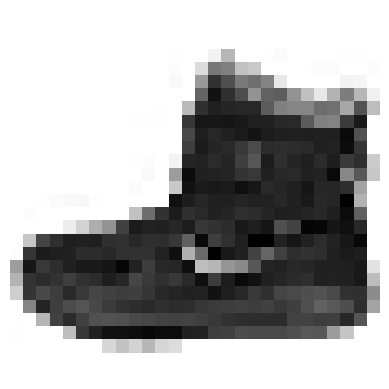

In [6]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

Each pixel intensity is represented as a byte (0 to 255):

In [7]:
X_train.dtype

dtype('uint8')

Let's scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255:

In [8]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

#### some samples from the Fashion MNIST dataset

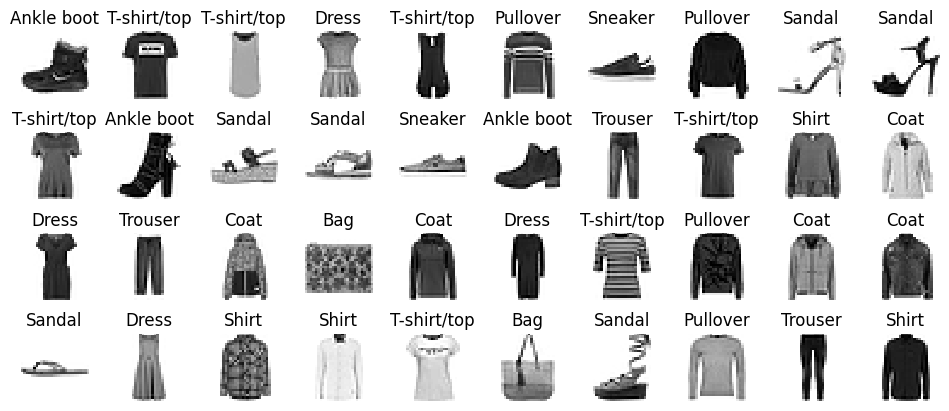

In [10]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

### Creating the model using the sequential API

In [11]:
# the random weights of the hidden layers and the output layer will be the same every time you run the notebook.
tf.random.set_seed(42)
# create a sequential model. the simplest kind of keras model for NNs that are just composed of a single stack of layers connected sequentially.
model = tf.keras.Sequential()
# the first layer (an input layer).
model.add(tf.keras.layers.Input(shape = [28,28]))
# Flatten Layer to convert each input image into a 1D array.
model.add(tf.keras.layers.Flatten())
# Dense hidden layer with 300 neurons, ReLU activation function.
model.add(tf.keras.layers.Dense(300, activation = "relu"))
# Dense hidden layer with 100 neurons, ReLU activation function.
model.add(tf.keras.layers.Dense(100, activation = "relu"))
# Dense output layer with 10 neurons(one per class), Softmax activation function.
model.add(tf.keras.layers.Dense(10, activation = "softmax"))

All global state managed by Keras is stored in a Keras session, which you can clear using tf.keras.backend.clear_session().
In particular, this resets the name counters

In [12]:
tf.keras.backend.clear_session()

In [13]:
# we can to pass a list of layers when creating the Sequential model.
# you can also drop the input layer and instead specify the input_shape in the first layer:

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28,28)),
    tf.keras.layers.Dense(300, activation = "relu"),
    tf.keras.layers.Dense(100, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
])

c:\Users\20100\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

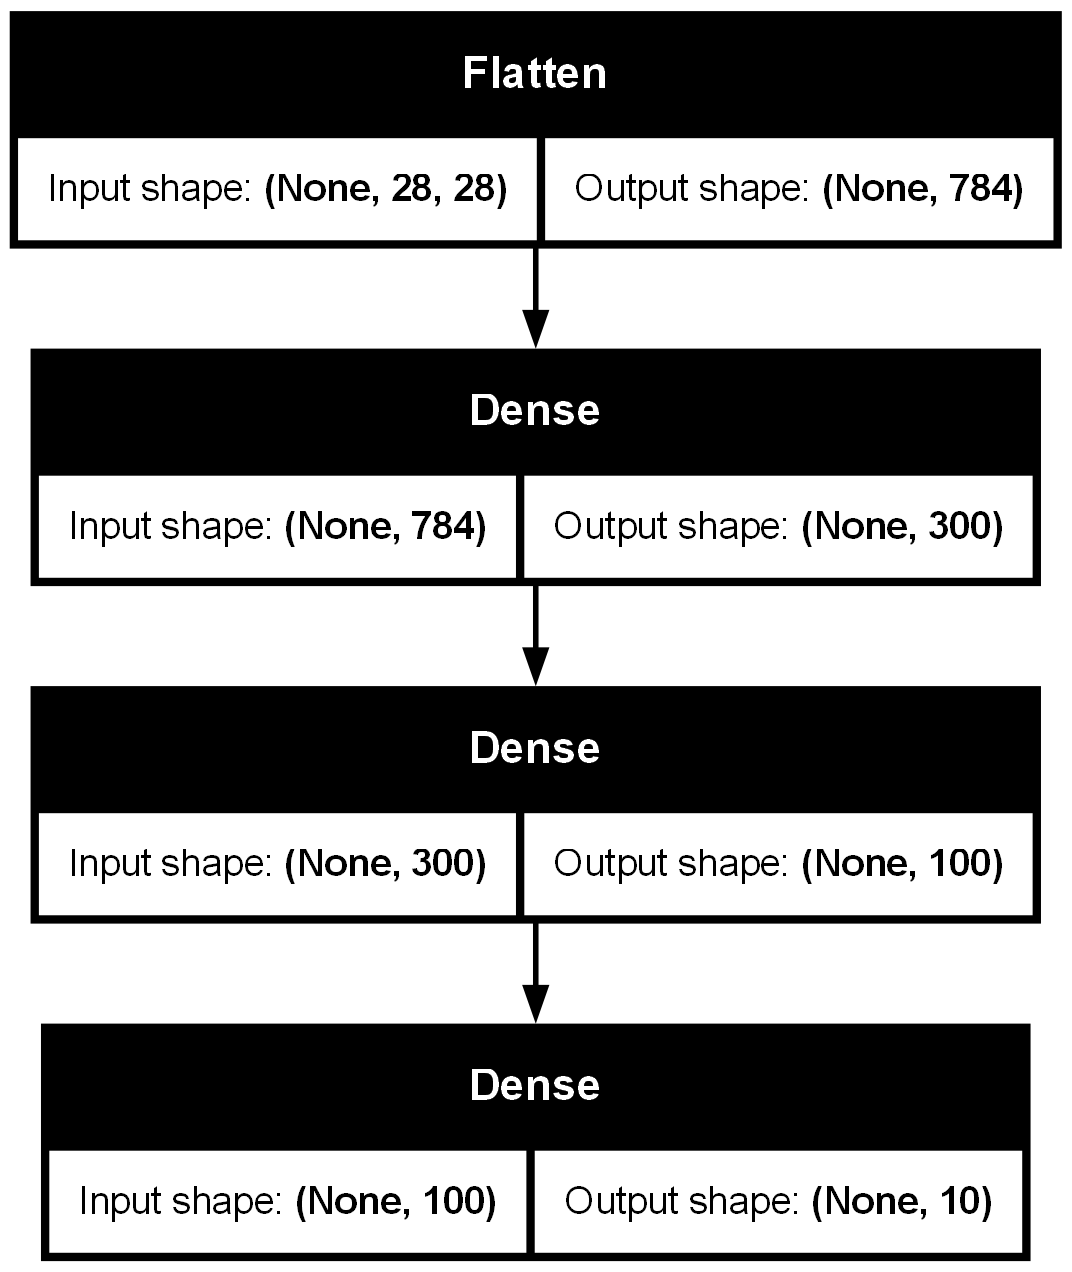

In [15]:
# another way to display the model's architecture
tf.keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

In [16]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [17]:
model.layers[1].name

'dense'

In [18]:
weights, biases = model.layers[1].get_weights()

In [19]:
weights

array([[-0.00301022, -0.01337283, -0.02383996, ..., -0.04314462,
         0.05904636, -0.04546838],
       [ 0.00693722,  0.02362327, -0.03427727, ..., -0.02968599,
        -0.03957984,  0.02200113],
       [-0.01605104, -0.05652164, -0.00312204, ..., -0.00373756,
        -0.0100347 , -0.03520245],
       ...,
       [ 0.01995338,  0.06812361, -0.02889725, ...,  0.05094361,
        -0.07191889,  0.06078517],
       [ 0.03485316,  0.04971419,  0.02911405, ...,  0.0038097 ,
         0.02959196,  0.01941019],
       [ 0.07016948, -0.07332636,  0.03082488, ...,  0.03412609,
         0.03607413, -0.01900106]], dtype=float32)

In [20]:
weights.shape

(784, 300)

In [21]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [22]:
biases.shape

(300,)

### Compiling the model

In [23]:
model.compile(loss = "sparse_categorical_crossentropy", optimizer = "sgd", metrics = ["accuracy"])

"""
[loss = "sparse_categorical_crossentropy"] == [loss = tf.keras.losses.sparse_categorical_crossentropy]
[optimizer = "sgd"] == [optimizer = tf.keras.optimizers.SGD()]
[metrics = ["accuracy"]] == [metrics = tf.keras.metrics.sparse_categorical_accuracy]
"""

'\n[loss = "sparse_categorical_crossentropy"] == [loss = tf.keras.losses.sparse_categorical_crossentropy]\n[optimizer = "sgd"] == [optimizer = tf.keras.optimizers.SGD()]\n[metrics = ["accuracy"]] == [metrics = tf.keras.metrics.sparse_categorical_accuracy]\n'

Training and evaluatingg the model

In [24]:
history = model.fit(X_train, y_train, epochs = 30, validation_data = (X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6882 - loss: 0.9964 - val_accuracy: 0.8288 - val_loss: 0.5021
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8278 - loss: 0.5007 - val_accuracy: 0.8390 - val_loss: 0.4531
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8438 - loss: 0.4487 - val_accuracy: 0.8470 - val_loss: 0.4319
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8532 - loss: 0.4199 - val_accuracy: 0.8496 - val_loss: 0.4160
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8599 - loss: 0.3996 - val_accuracy: 0.8548 - val_loss: 0.4032
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8654 - loss: 0.3833 - val_accuracy: 0.8576 - val_loss: 0.3940
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8702 - loss: 0.3698 - val_accuracy: 0.8606 - val_loss: 0.3859
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8740 - loss: 0.3579 - 

In [25]:
# the batch size is 32 by default, and since the training set has 55,000 images 
55000/32

1718.75

the model goes through 1719 batches per epoch: 1718 of size 32, and 1 of size 24.

In [26]:
# histroy.params  ==> the training parameters.
# history.epoch   ==> the list of epochs it went through.
# history.history ==> the loss and the extra metrics
history.history

{'accuracy': [0.7672545313835144,
  0.8339272737503052,
  0.8472545742988586,
  0.8558909296989441,
  0.8615454435348511,
  0.8668363690376282,
  0.8713091015815735,
  0.8752909302711487,
  0.878818154335022,
  0.8817272782325745,
  0.884181797504425,
  0.8870182037353516,
  0.8890363574028015,
  0.8918181657791138,
  0.8940908908843994,
  0.8962181806564331,
  0.8985272645950317,
  0.8999636173248291,
  0.9021818041801453,
  0.9037454724311829,
  0.9058727025985718,
  0.9075090885162354,
  0.9094545245170593,
  0.9111818075180054,
  0.9127636551856995,
  0.9147999882698059,
  0.9163818359375,
  0.9180908799171448,
  0.9196000099182129,
  0.9209636449813843],
 'loss': [0.711974561214447,
  0.481257826089859,
  0.43754029273986816,
  0.411557137966156,
  0.39254704117774963,
  0.37716934084892273,
  0.3642767667770386,
  0.3528609275817871,
  0.3424796164035797,
  0.33295968174934387,
  0.32415443658828735,
  0.3159313499927521,
  0.30844131112098694,
  0.3012235760688782,
  0.294550448

If you use this dictionary to create a Pandas DataFrame and call its plot() method, you get **the learning curves**

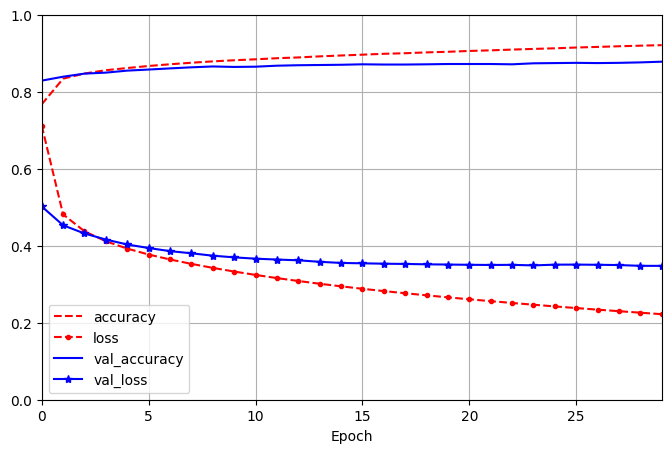

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  
plt.show()

In [29]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8747 - loss: 0.3630


[0.3616434633731842, 0.8744000196456909]

### Using the model to make predictions

In [30]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.25, 0.  , 0.01, 0.  , 0.75],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [31]:
y_pred = y_proba.argmax(axis = -1)
y_pred

array([9, 2, 1])

In [32]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [33]:
y_true = y_test[:3]
y_true

array([9, 2, 1], dtype=uint8)